In [32]:
# 6.1.1 위스콘신 유방암 데이터셋
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                 'machine-learning-databases'
                 '/breast-cancer-wisconsin/wdbc.data', header=None)

In [33]:
df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [34]:
from sklearn.preprocessing import LabelEncoder
X = df.loc[:, 2:].values
y = df.loc[:, 1].values
le = LabelEncoder()
le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.20,
                                                    stratify=y,
                                                    random_state=1)

In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [37]:
# 6.1.2 파이프라인으로 변환기와 추정기 연결
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(random_state=1))
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
test_acc = pipe_lr.score(X_test, y_test)
print(f'테스트정확도: {test_acc:.3f}')

테스트정확도: 0.956


In [38]:
# 6.2.2 k 겹 교차검증
import numpy as np
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []
for k, (train_index, test_index) in enumerate(kfold):
    pipe_lr.fit(X_train[train_index], y_train[train_index])
    score = pipe_lr.score(X_train[test_index], y_train[test_index])
    print(f"각 폴드의 점수: {score}")
    scores.append(score)

print(f"평균 정확도: {np.mean(scores):.3f} +/- {np.std(scores):.3f}")

각 폴드의 점수: 0.9347826086956522
각 폴드의 점수: 0.9347826086956522
각 폴드의 점수: 0.9565217391304348
각 폴드의 점수: 0.9565217391304348
각 폴드의 점수: 0.9347826086956522
각 폴드의 점수: 0.9555555555555556
각 폴드의 점수: 0.9777777777777777
각 폴드의 점수: 0.9333333333333333
각 폴드의 점수: 0.9555555555555556
각 폴드의 점수: 0.9555555555555556
평균 정확도: 0.950 +/- 0.014


In [39]:
# 6.2.2 k 겹 교차검증(LOOCV)
# LOOCV는 훈련 세트의 각 샘플을 한 번씩 테스트 세트로 사용하는 교차 검증 방법입니다.
# sklearn.model_selection.LeaveOneOut을 사용하여 올바르게 구현할 수 있습니다.

import numpy as np
from sklearn.model_selection import LeaveOneOut # LeaveOneOut 사용

# LOOCV를 위해 LeaveOneOut 객체 생성
loo = LeaveOneOut()
kfold_loocv = loo.split(X_train, y_train)

loocv_scores = []
for k, (train_index, test_index) in enumerate(kfold_loocv):
    # 각 폴드마다 파이프라인을 재학습
    pipe_lr.fit(X_train[train_index], y_train[train_index])
    # 테스트 세트에서 점수 계산 (각 테스트 세트는 하나의 샘플만 포함)
    score = pipe_lr.score(X_train[test_index], y_train[test_index])
    loocv_scores.append(score)

print(f"LOOCV 정확도: {np.mean(loocv_scores):.3f} +/- {np.std(loocv_scores):.3f}")

LOOCV 정확도: 0.947 +/- 0.224


In [40]:
# 6.2.2 계층적 k 겹 교차검증(stratified)
import numpy as np
from sklearn.model_selection import StratifiedKFold

# pipe_lr은 이미 정의되어 있으므로 다시 생성할 필요가 없습니다.
# pipe_lr = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression(random_state=1))

kfold_stratified = StratifiedKFold(n_splits=10, random_state=1, shuffle=True).split(X_train, y_train)
stratified_scores = []

for k, (train_index, test_index) in enumerate(kfold_stratified):
    # 각 폴드마다 파이프라인을 재학습
    pipe_lr.fit(X_train[train_index], y_train[train_index])
    # 테스트 세트에서 점수 계산
    score = pipe_lr.score(X_train[test_index], y_train[test_index])
    print(f'각 폴드의 점수 (Stratified): {score:.3f}')
    stratified_scores.append(score)

print(f"평균 정확도 (Stratified): {np.mean(stratified_scores):.3f} +/- {np.std(stratified_scores):.3f}")

각 폴드의 점수 (Stratified): 0.913
각 폴드의 점수 (Stratified): 1.000
각 폴드의 점수 (Stratified): 0.957
각 폴드의 점수 (Stratified): 0.978
각 폴드의 점수 (Stratified): 0.891
각 폴드의 점수 (Stratified): 0.933
각 폴드의 점수 (Stratified): 0.933
각 폴드의 점수 (Stratified): 0.978
각 폴드의 점수 (Stratified): 0.978
각 폴드의 점수 (Stratified): 0.911
평균 정확도 (Stratified): 0.947 +/- 0.034


In [41]:
# cross_val_score 이용한 간단한 계층별 k-겹 교차검증
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# pipe_lr은 이미 정의되어 있습니다.

kfold_stratified_cv = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)

cv_scores = cross_val_score(estimator=pipe_lr,
                            X=X_train,
                            y=y_train,
                            cv=kfold_stratified_cv,
                            n_jobs=1) # n_jobs=-1은 모든 CPU 코어를 사용합니다.

print('각 폴드의 점수 (cross_val_score):')
for i, score in enumerate(cv_scores):
    print(f'  폴드 {i+1}: {score:.3f}')
print(f'평균 정확도 (cross_val_score): {np.mean(cv_scores):.3f} +/- {np.std(cv_scores):.3f}')

각 폴드의 점수 (cross_val_score):
  폴드 1: 0.913
  폴드 2: 1.000
  폴드 3: 0.957
  폴드 4: 0.978
  폴드 5: 0.891
  폴드 6: 0.933
  폴드 7: 0.933
  폴드 8: 0.978
  폴드 9: 0.978
  폴드 10: 0.911
평균 정확도 (cross_val_score): 0.947 +/- 0.034


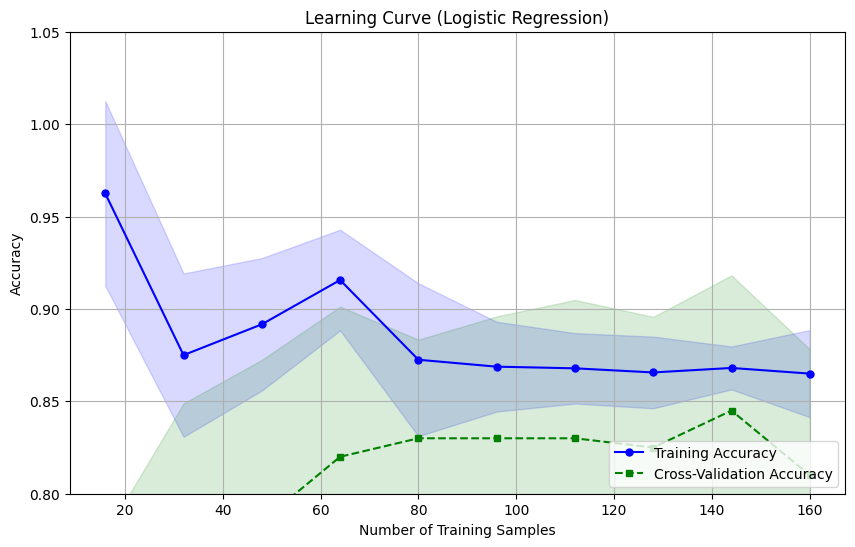

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold # StratifiedKFold 추가
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# 1. 간단한 가상 데이터셋 생성
X_sample, y_sample = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42) # n_samples 증가

# 2. 로지스틱 회귀 모델 정의
model = LogisticRegression(solver='liblinear', random_state=1)

# 3. 학습 곡선 계산
# StratifiedKFold를 사용하여 클래스 비율을 유지합니다.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1) # cv 객체 생성

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_sample,
    y=y_sample,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, # StratifiedKFold 객체 전달
    n_jobs=1)

# 훈련 점수와 테스트 점수의 평균 및 표준편차 계산
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Cross-Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Learning Curve (Logistic Regression)')
plt.ylim([0.8, 1.05])
plt.show()

### SVM (Support Vector Machine) 모델과 파라미터 C

`C` 파라미터는 SVM에서 오분류에 대한 페널티를 조절하는 역할을 합니다.

*   **`C` 값이 작을수록**: 마진(Margin)이 넓어져 더 많은 오분류를 허용하고, 모델의 일반화 성능이 좋아질 수 있습니다 (과소적합 가능성).
*   **`C` 값이 클수록**: 마진이 좁아져 훈련 데이터를 더 엄격하게 분류하려고 하며, 오분류를 적게 만듭니다 (과적합 가능성).

아래 코드는 `C=1.0`인 `SVC` 모델을 생성하고 훈련하는 예시입니다.

In [43]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 가상 데이터셋 사용 (이전 셀에서 X_sample, y_sample 생성됨)
# 만약 데이터가 없다면 아래 주석을 해제하여 다시 생성합니다.
# from sklearn.datasets import make_classification
# X_sample, y_sample = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)

# 훈련 세트와 테스트 세트로 분할
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample)

# 데이터 스케일링 (SVM은 스케일에 민감합니다)
scaler = StandardScaler()
X_train_svm_scaled = scaler.fit_transform(X_train_svm)
X_test_svm_scaled = scaler.transform(X_test_svm)

# C=1.0인 SVC 모델 정의 및 훈련
svm_model = SVC(kernel='linear', C=1.0, random_state=1) # kernel='linear'는 선형 SVM을 의미합니다.
svm_model.fit(X_train_svm_scaled, y_train_svm)

# 예측 및 정확도 평가
y_pred_svm = svm_model.predict(X_test_svm_scaled)
accuracy = accuracy_score(y_test_svm, y_pred_svm)

print(f"SVM 모델 (C=1.0)의 테스트 정확도: {accuracy:.3f}")

# 다른 C 값으로도 시도해 볼 수 있습니다 (예: C=0.1 또는 C=100.0)

SVM 모델 (C=1.0)의 테스트 정확도: 0.900


### SVM `C` 파라미터 검증 곡선

`C` 파라미터는 SVM 모델의 복잡성을 제어합니다. `validation_curve`를 사용하여 `C` 값의 변화가 모델의 훈련 및 교차 검증 정확도에 미치는 영향을 시각화할 수 있습니다.

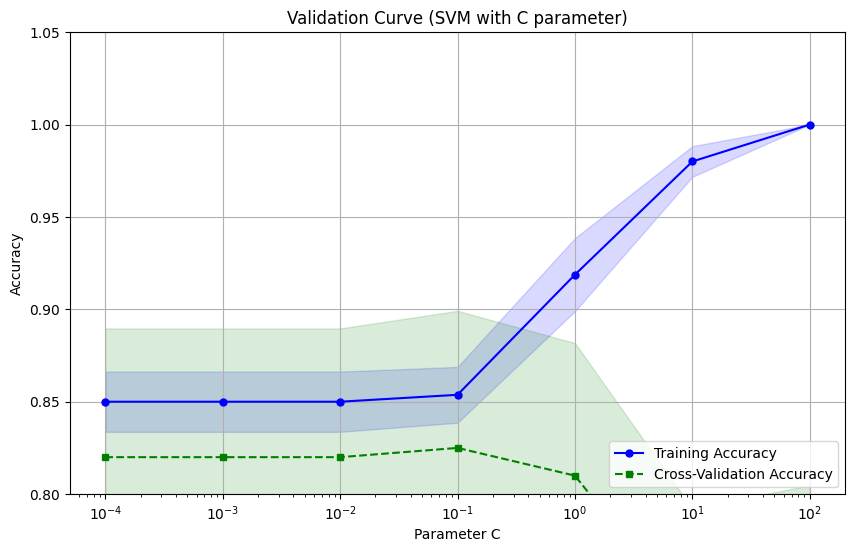

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import validation_curve, StratifiedKFold # StratifiedKFold 추가
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. 이전과 동일한 가상 데이터셋 사용
# X_sample, y_sample은 이전 셀에서 이미 생성되었습니다.
# 만약 다시 생성해야 한다면 아래 주석을 해제하세요.
# from sklearn.datasets import make_classification
# X_sample, y_sample = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)

# 2. SVM 모델 파이프라인 정의
# SVM은 스케일링에 민감하므로 StandardScaler를 파이프라인에 포함합니다.
pipe_svm = make_pipeline(StandardScaler(), SVC(random_state=1))

# 3. C 파라미터 범위 설정
param_range = np.logspace(-4, 2, 7) # 10^-4 부터 10^2 까지 7개의 C 값 (0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0)

# 4. 검증 곡선 계산
# StratifiedKFold를 사용하여 클래스 비율을 유지합니다.
cv_vc = StratifiedKFold(n_splits=5, shuffle=True, random_state=1) # cv 객체 생성

train_scores, test_scores = validation_curve(
    estimator=pipe_svm,
    X=X_sample,
    y=y_sample,
    param_name='svc__C', # 파이프라인에서 SVC 모델의 C 파라미터를 지정
    param_range=param_range,
    cv=cv_vc,
    n_jobs=1)

# 훈련 점수와 테스트 점수의 평균 및 표준편차 계산
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. 검증 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(param_range, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Cross-Validation Accuracy')
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.grid()
plt.xscale('log') # C 파라미터가 로그 스케일이므로 x축도 로그 스케일로 설정
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Validation Curve (SVM with C parameter)')
plt.ylim([0.8, 1.05])
plt.show()

### 다른 모델 (랜덤 포레스트)에 학습 곡선 적용

이번에는 `RandomForestClassifier` 모델을 사용하여 학습 곡선을 그려보겠습니다. `LogisticRegression`과 비교하여 어떤 차이가 있는지 확인할 수 있습니다.

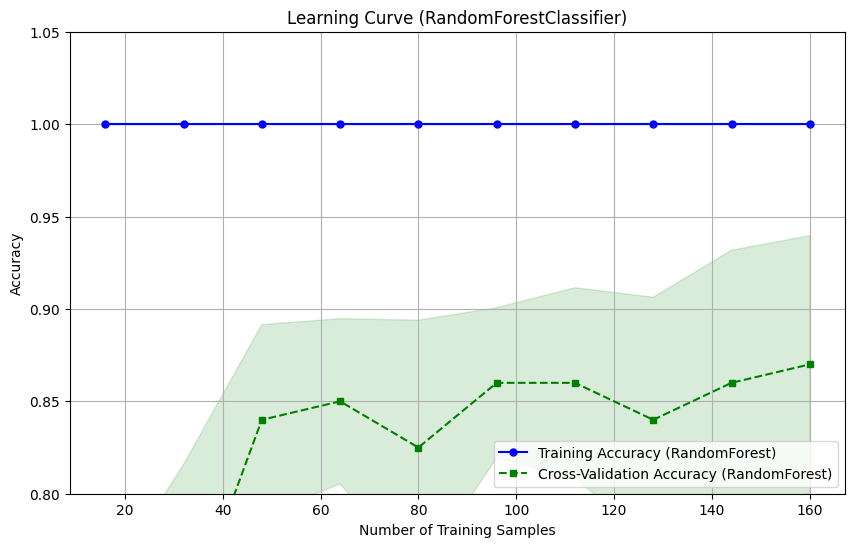

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier # RandomForestClassifier 임포트
from sklearn.datasets import make_classification

# 1. 이전과 동일한 가상 데이터셋 사용
# X_sample, y_sample은 이전 셀에서 이미 생성되었습니다.
# 만약 다시 생성해야 한다면 아래 주석을 해제하세요.
# X_sample, y_sample = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)

# 2. RandomForestClassifier 모델 정의
# 하이퍼파라미터는 기본값 또는 임의의 값으로 설정할 수 있습니다.
model_rf = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)

# 3. 학습 곡선 계산
# StratifiedKFold를 사용하여 클래스 비율을 유지합니다.
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    estimator=model_rf,
    X=X_sample,
    y=y_sample,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_rf,
    n_jobs=1) # n_jobs=-1로 설정하면 모든 CPU 코어를 사용할 수 있습니다.

# 훈련 점수와 테스트 점수의 평균 및 표준편차 계산
train_mean_rf = np.mean(train_scores_rf, axis=1)
train_std_rf = np.std(train_scores_rf, axis=1)
test_mean_rf = np.mean(test_scores_rf, axis=1)
test_std_rf = np.std(test_scores_rf, axis=1)

# 4. 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_rf, train_mean_rf, color='blue', marker='o', markersize=5, label='Training Accuracy (RandomForest)')
plt.fill_between(train_sizes_rf, train_mean_rf + train_std_rf, train_mean_rf - train_std_rf, alpha=0.15, color='blue')

plt.plot(train_sizes_rf, test_mean_rf, color='green', linestyle='--', marker='s', markersize=5, label='Cross-Validation Accuracy (RandomForest)')
plt.fill_between(train_sizes_rf, test_mean_rf + test_std_rf, test_mean_rf - test_std_rf, alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Learning Curve (RandomForestClassifier)')
plt.ylim([0.8, 1.05])
plt.show()

In [46]:
# 6.4 그리드 서치를 사용한 머신 러닝 모델 세부 튜닝

In [47]:
# 6.4.1 그리드 서치를 사용한 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))

# param_grid 정의 예시
# SVC 모델의 하이퍼파라미터 'C'와 'kernel'에 대한 후보 값들을 설정합니다.
param_grid = [{
    'svc__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'svc__kernel': ['linear']
}, {
    'svc__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'svc__gamma': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'svc__kernel': ['rbf']
}]

print("정의된 param_grid:")
for i, params in enumerate(param_grid):
    print(f"  조합 {i+1}: {params}")

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=10,
                  n_jobs=-1) # Use all available CPU cores

# Fit the GridSearchCV object to the training data
gs.fit(X_train, y_train)

# Print the best parameters found by the grid search
print(f"최적의 하이퍼파라미터: {gs.best_params_}")

# Print the best cross-validation accuracy score
print(f"최고 교차 검증 정확도: {gs.best_score_:.3f}")

# Get the best estimator from the GridSearchCV object
best_estimator = gs.best_estimator_

# Evaluate the accuracy of the best estimator on the test set
test_accuracy = best_estimator.score(X_test, y_test)
print(f"테스트 세트 정확도 (최적 모델): {test_accuracy:.3f}")

정의된 param_grid:
  조합 1: {'svc__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'svc__kernel': ['linear']}
  조합 2: {'svc__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'svc__gamma': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'svc__kernel': ['rbf']}
최적의 하이퍼파라미터: {'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
최고 교차 검증 정확도: 0.985
테스트 세트 정확도 (최적 모델): 0.974


In [48]:
# 6.4.2 랜덤 서치를 사용한 하이퍼파라미터 튜닝
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# pipe_svc는 이미 정의되어 있으므로 다시 생성할 필요가 없습니다.
# pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))

# param_distributions 정의 예시
# SVC 모델의 하이퍼파라미터 'C', 'gamma', 'kernel'에 대한 분포를 설정합니다.
param_distributions = {
    'svc__C': uniform(loc=0.001, scale=100.0), # 0.001에서 100.0까지 균등 분포
    'svc__gamma': uniform(loc=0.0001, scale=10.0), # 0.0001에서 10.0까지 균등 분포
    'svc__kernel': ['linear', 'rbf'] # 'linear' 또는 'rbf' 중 선택
}

print("정의된 param_distributions:")
for key, value in param_distributions.items():
    # scipy.stats의 연속 분포 객체인지 확인 (loc과 scale 속성을 통해)
    if hasattr(value, 'kwds') and 'loc' in value.kwds and 'scale' in value.kwds:
        print(f"  {key}: 균등 분포 (범위: [{value.kwds['loc']:.4f}, {value.kwds['loc'] + value.kwds['scale']:.4f}])")
    elif isinstance(value, list):
        print(f"  {key}: {value}")
    else:
        # 그 외의 경우 (예: 다른 유형의 분포 또는 예상치 못한 타입) 객체 자체를 출력
        print(f"  {key}: {value}")

rs = RandomizedSearchCV(estimator=pipe_svc,
                        param_distributions=param_distributions,
                        n_iter=50,  # 시도할 파라미터 조합의 수
                        scoring='accuracy',
                        cv=10,
                        random_state=1,
                        n_jobs=-1) # Use all available CPU cores

# Fit the RandomizedSearchCV object to the training data
rs.fit(X_train, y_train)

# Print the best parameters found by the random search
# Convert numpy floats to standard Python floats for cleaner output
cleaned_best_params = {k: v.item() if isinstance(v, np.float64) else v for k, v in rs.best_params_.items()}
print(f"\n최적의 하이퍼파라미터: {cleaned_best_params}")

# Print the best cross-validation accuracy score
print(f"최고 교차 검증 정확도: {rs.best_score_:.3f}")

# Get the best estimator from the RandomizedSearchCV object
best_estimator_rs = rs.best_estimator_

# Evaluate the accuracy of the best estimator on the test set
test_accuracy_rs = best_estimator_rs.score(X_test, y_test)
print(f"테스트 세트 정확도 (최적 모델): {test_accuracy_rs:.3f}")

정의된 param_distributions:
  svc__C: 균등 분포 (범위: [0.0010, 100.0010])
  svc__gamma: 균등 분포 (범위: [0.0001, 10.0001])
  svc__kernel: ['linear', 'rbf']

최적의 하이퍼파라미터: {'svc__C': 1.9376957870297074, 'svc__gamma': 6.788455329398909, 'svc__kernel': 'linear'}
최고 교차 검증 정확도: 0.976
테스트 세트 정확도 (최적 모델): 0.974


In [49]:
# 6.4.3 SH 방식을 사용한 자원 효율적인 하이퍼파라미터 탐색

### 6.4.3 SH (Successive Halving) 방식을 사용한 자원 효율적인 하이퍼파라미터 탐색

`HalvingRandomSearchCV`는 `RandomizedSearchCV`와 `Successive Halving` 기술을 결합하여 하이퍼파라미터 탐색을 더욱 효율적으로 수행합니다. 이는 제한된 자원(예: 훈련 데이터의 일부)으로 많은 하이퍼파라미터 조합을 빠르게 평가하고, 유망한 조합에 더 많은 자원을 할당하여 최종 모델을 찾습니다.

주요 파라미터:
- **`estimator`**: 훈련할 모델 객체 (예: `pipe_svc`).
- **`param_distributions`**: 탐색할 하이퍼파라미터의 분포. `RandomizedSearchCV`와 유사하게 정의합니다.
- **`factor`**: 각 반복(iteration)에서 자원 증가량 (예: 2는 자원을 두 배로 늘림) 및 후보 수 감소량 (예: 2는 후보 수를 절반으로 줄임)을 제어합니다. `factor >= 2`여야 합니다.
- **`min_resources`**: 각 하이퍼파라미터 조합이 처음으로 훈련될 때 사용되는 최소 자원(샘플 수 또는 특성 수)입니다. 일반적으로 `n_samples`가 사용됩니다.
- **`resource`**: `min_resources`와 함께 사용되며, 어떤 자원(예: `n_samples`, `n_features`, `n_estimators`)을 점진적으로 늘릴 것인지 지정합니다. 기본값은 `n_samples`입니다.
- **`n_candidates`**: 탐색할 초기 하이퍼파라미터 조합의 최대 수입니다. `RandomizedSearchCV`의 `n_iter`와 유사하지만, `Successive Halving`의 각 반복에서 이 후보들이 줄어듭니다.
- **`max_resources`**: 각 하이퍼파라미터 조합이 최대로 사용할 수 있는 자원입니다. 지정하지 않으면 전체 훈련 세트가 사용됩니다.

아래 코드는 `HalvingRandomSearchCV`를 사용하여 SVC 모델의 `C`, `gamma`, `kernel` 하이퍼파라미터를 탐색하는 예시입니다.

In [50]:
from scipy.stats import uniform
from sklearn.experimental import enable_halving_search_cv  # 이 줄은 필수입니다!
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# pipe_svc는 이미 정의되어 있으므로 다시 생성할 필요가 없습니다.
# pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))

# param_distributions 정의 예시
# SVC 모델의 하이퍼파라미터 'C', 'gamma', 'kernel'에 대한 분포를 설정합니다.
param_distributions = {
    'svc__C': uniform(loc=0.001, scale=100.0),  # 0.001에서 100.0까지 균등 분포
    'svc__gamma': uniform(loc=0.0001, scale=10.0),  # 0.0001에서 10.0까지 균등 분포
    'svc__kernel': ['linear', 'rbf']  # 'linear' 또는 'rbf' 중 선택
}

print("정의된 param_distributions:")
for key, value in param_distributions.items():
    # scipy.stats의 연속 분포 객체인지 확인 (loc과 scale 속성을 통해)
    if hasattr(value, 'kwds') and 'loc' in value.kwds and 'scale' in value.kwds:
        print(f"  {key}: 균등 분포 (범위: [{value.kwds['loc']:.4f}, {value.kwds['loc'] + value.kwds['scale']:.4f}])")
    elif isinstance(value, list):
        print(f"  {key}: {value}")
    else:
        # 그 외의 경우 (예: 다른 유형의 분포 또는 예상치 못한 타입) 객체 자체를 출력
        print(f"  {key}: {value}")

hrs = HalvingRandomSearchCV(estimator=pipe_svc,
                            param_distributions=param_distributions,
                            factor=3,  # 자원 증가량 및 후보 수 감소량
                            min_resources='smallest',  # 각 후보가 시작하는 최소 자원 (예: 훈련 샘플 수)
                            scoring='accuracy',
                            cv=10,
                            random_state=1,
                            n_jobs=-1)  # Use all available CPU cores

# Fit the HalvingRandomSearchCV object to the training data
hrs.fit(X_train, y_train)

# Print the best parameters found by the HalvingRandomSearchCV
cleaned_best_params_hrs = {k: v.item() if isinstance(v, np.float64) else v for k, v in hrs.best_params_.items()}
print(f"\n최적의 하이퍼파라미터 (SH): {cleaned_best_params_hrs}")

# Print the best cross-validation accuracy score
print(f"최고 교차 검증 정확도 (SH): {hrs.best_score_:.3f}")

# Get the best estimator from the HalvingRandomSearchCV object
best_estimator_hrs = hrs.best_estimator_

# Evaluate the accuracy of the best estimator on the test set
test_accuracy_hrs = best_estimator_hrs.score(X_test, y_test)
print(f"테스트 세트 정확도 (최적 모델, SH): {test_accuracy_hrs:.3f}")

정의된 param_distributions:
  svc__C: 균등 분포 (범위: [0.0010, 100.0010])
  svc__gamma: 균등 분포 (범위: [0.0001, 10.0001])
  svc__kernel: ['linear', 'rbf']

최적의 하이퍼파라미터 (SH): {'svc__C': 9.281080864073791, 'svc__gamma': 5.18162548941889, 'svc__kernel': 'linear'}
최고 교차 검증 정확도 (SH): 0.960
테스트 세트 정확도 (최적 모델, SH): 0.974


In [51]:
# 6.4.3 SH 방식을 사용한 자원 효율적인 하이퍼파라미터 탐색

오차 행렬:
[[71  1]
 [ 4 38]]


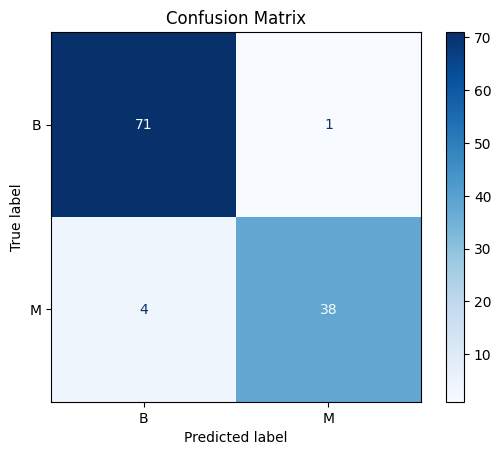

In [52]:
# 6.5.1 오차행렬

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# y_test와 y_pred는 이미 이전 셀에서 생성되었습니다 (pipe_lr 모델)
# y_test: 실제 레이블
# y_pred: 모델의 예측 레이블

# 오차 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 오차 행렬 출력
print("오차 행렬:")
print(cm)

# 오차 행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [53]:
# 분류모델의 정밀도와 재현율 최적화

from sklearn.metrics import make_scorer, precision_score, recall_score
from sklearn.model_selection import cross_val_score
import numpy as np

# pipe_lr, X_train, y_train은 이전 셀에서 정의되었습니다.
# 참고: LabelEncoder로 'M'이 1, 'B'가 0으로 인코딩되었을 수 있습니다.
# 실제 레이블을 기준으로 pos_label을 설정합니다.
# 여기서는 'M' (악성)을 양성 클래스로 가정합니다.

# 정밀도(Precision) 스코어러 생성
# 'M'이 긍정 클래스라고 가정하고 긍정 클래스에 대한 정밀도를 계산합니다.
precision_scorer = make_scorer(precision_score, pos_label='M')

# 재현율(Recall) 스코어러 생성
# 'M'이 긍정 클래스라고 가정하고 긍정 클래스에 대한 재현율을 계산합니다.
recall_scorer = make_scorer(recall_score, pos_label='M')

print("파이프라인 모델을 사용한 정밀도 교차 검증:")
precision_scores = cross_val_score(estimator=pipe_lr,
                                   X=X_train,
                                   y=y_train,
                                   cv=10,
                                   scoring=precision_scorer,
                                   n_jobs=1)
print(f"  각 폴드의 정밀도: {precision_scores}")
print(f"  평균 정밀도: {np.mean(precision_scores):.3f} +/- {np.std(precision_scores):.3f}")

print("\n파이프라인 모델을 사용한 재현율 교차 검증:")
recall_scores = cross_val_score(estimator=pipe_lr,
                                X=X_train,
                                y=y_train,
                                cv=10,
                                scoring=recall_scorer,
                                n_jobs=1)
print(f"  각 폴드의 재현율: {recall_scores}")
print(f"  평균 재현율: {np.mean(recall_scores):.3f} +/- {np.std(recall_scores):.3f}")

파이프라인 모델을 사용한 정밀도 교차 검증:
  각 폴드의 정밀도: [0.85       0.85       1.         1.         1.         0.94117647
 0.94444444 0.9375     0.94117647 1.        ]
  평균 정밀도: 0.946 +/- 0.055

파이프라인 모델을 사용한 재현율 교차 검증:
  각 폴드의 재현율: [1.         1.         0.88235294 0.88235294 0.82352941 0.94117647
 1.         0.88235294 0.94117647 0.88235294]
  평균 재현율: 0.924 +/- 0.059
